In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [29]:
df = pd.read_csv(r"/credit_risk_dataset.csv")

In [5]:
print("Shape:", df.shape)
print()
display(df.head())
print()
df.info()

Shape: (32581, 12)



,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
print(df["person_home_ownership"].value_counts())
print()
print(df["loan_intent"].value_counts())
print()
print(df["loan_grade"].value_counts())
print()
print(df["cb_person_default_on_file"].value_counts())
print()


person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64



In [7]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [8]:
print(df.isnull().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [30]:
df = df.dropna()
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


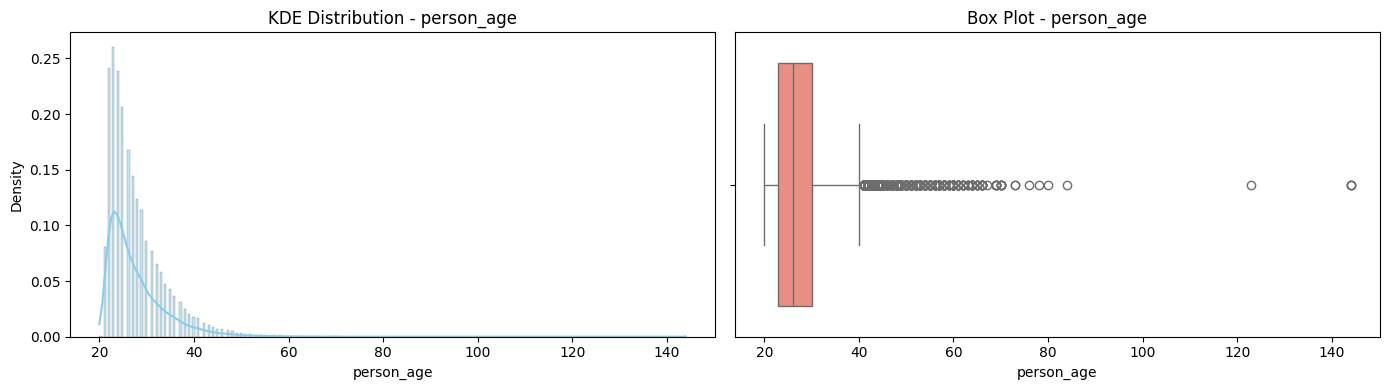

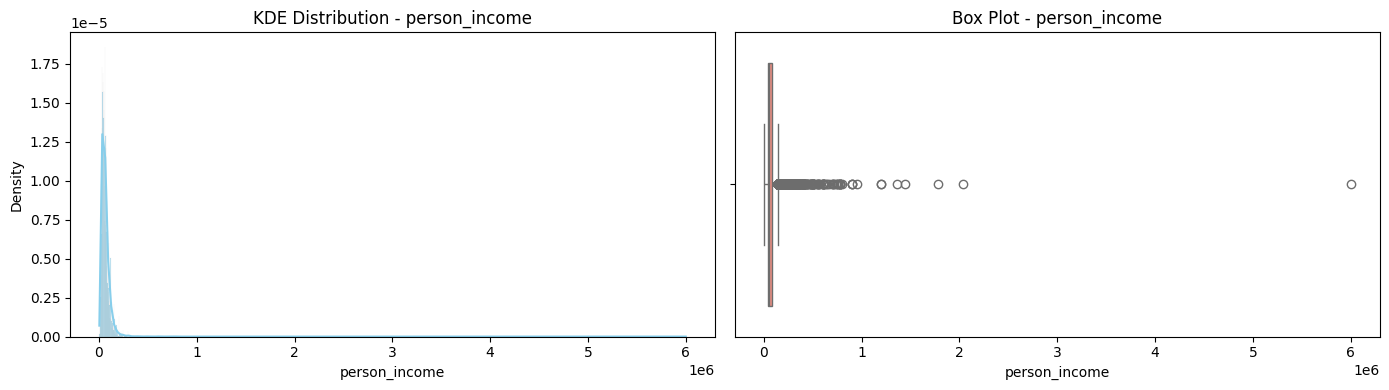

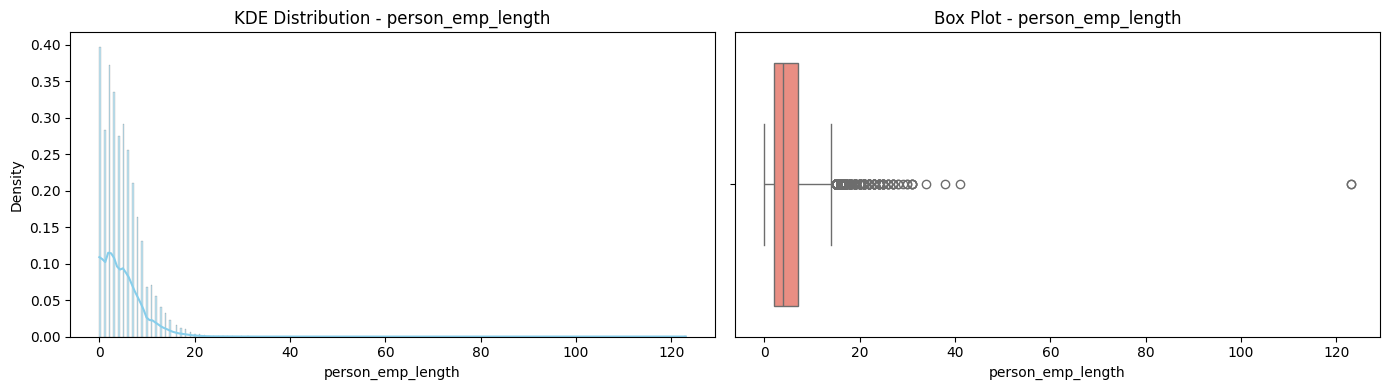

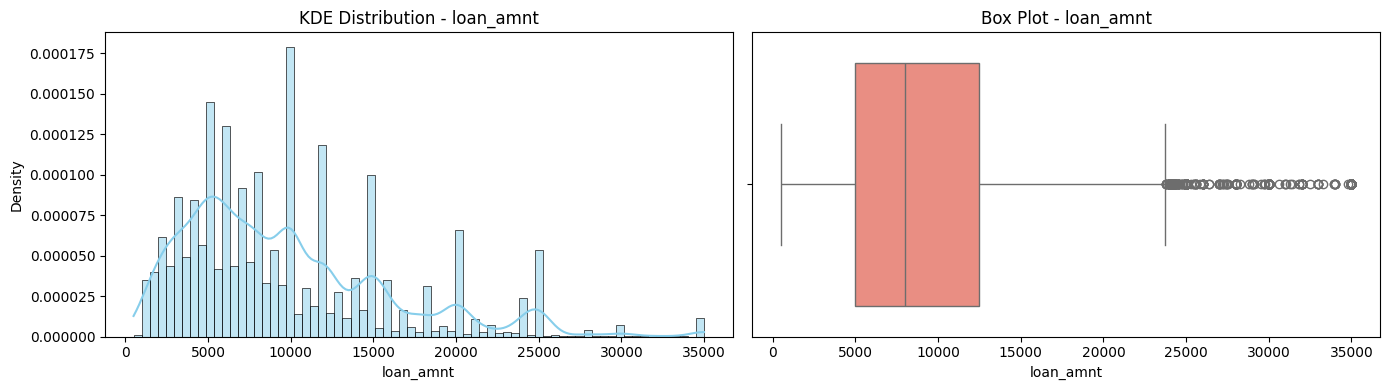

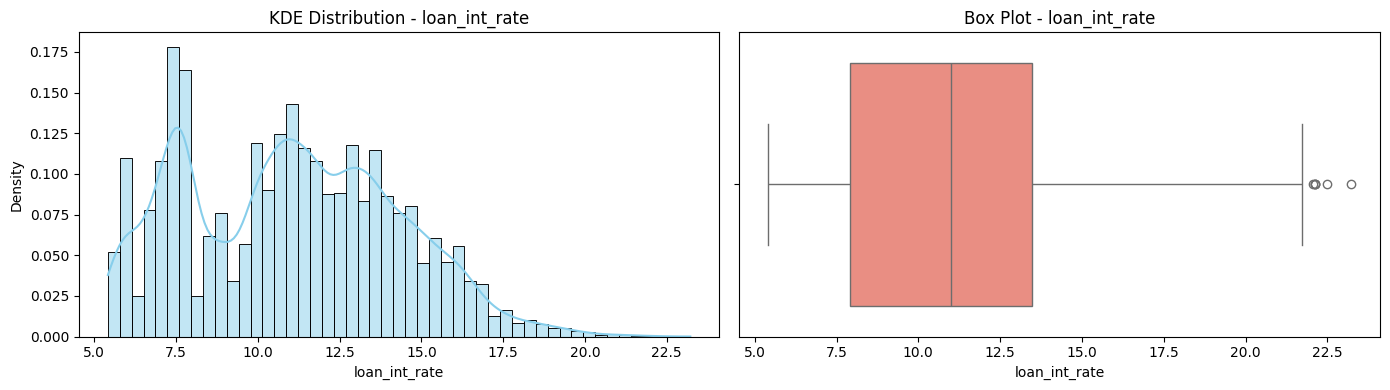

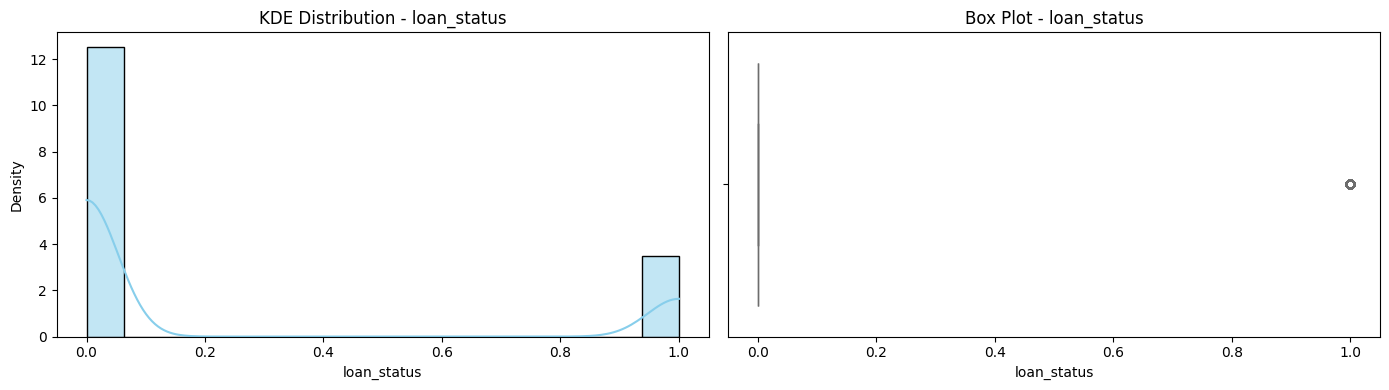

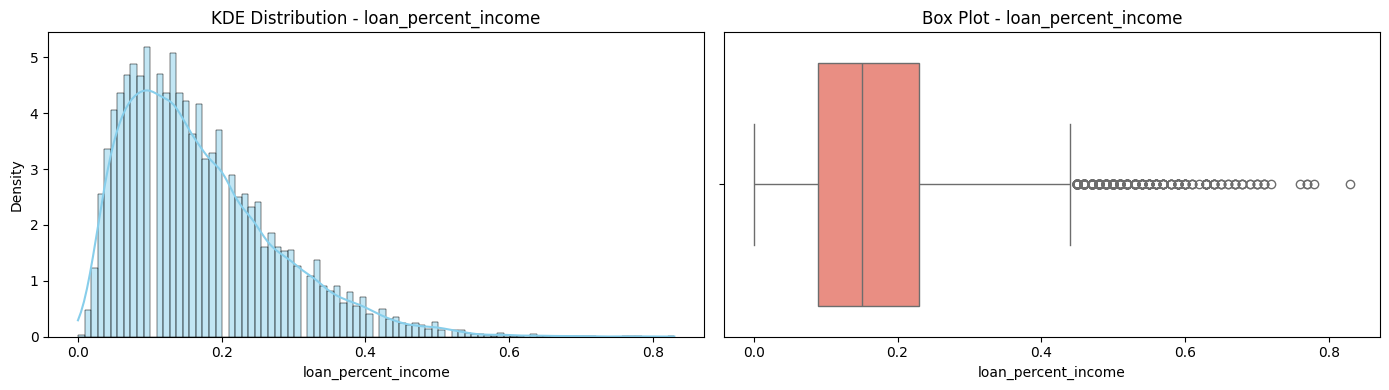

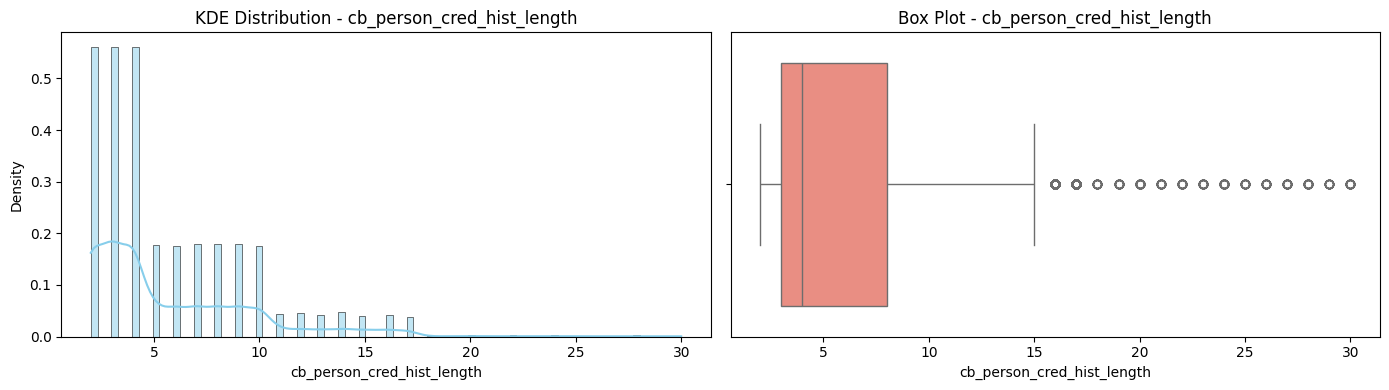

In [10]:
num_cols = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns
# Loop through each numerical column and plot KDE + Boxplot side by side
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # 1. KDE / Density Plot
    sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue', stat='density')
    axes[0].set_title(f'KDE Distribution - {col}', fontsize=12)
    axes[0].set_xlabel(col)

    # 2. Horizontal Box Plot
    sns.boxplot(x=df[col], ax=axes[1], color='salmon')
    axes[1].set_title(f'Box Plot - {col}', fontsize=12)
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()


==================== person_home_ownership ====================
                       Count  Percentage (%)
person_home_ownership                       
RENT                   14551           50.81
MORTGAGE               11801           41.21
OWN                     2192            7.65
OTHER                     94            0.33


/tmp/ipykernel_851/2218469318.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette='Set2', order=val_counts.index)


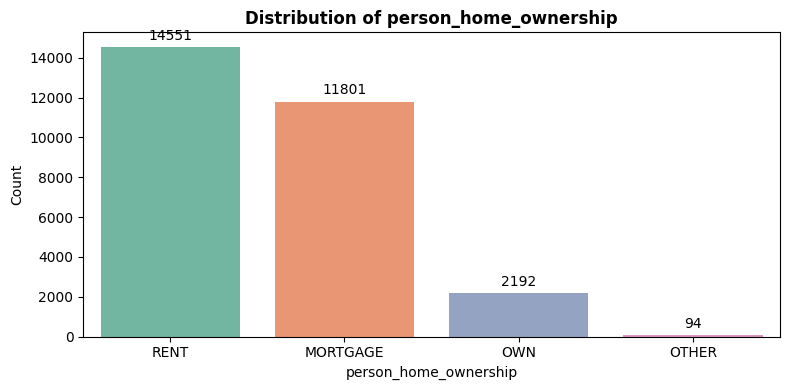


==================== loan_intent ====================
                   Count  Percentage (%)
loan_intent                             
EDUCATION           5704           19.92
MEDICAL             5293           18.48
VENTURE             5001           17.46
PERSONAL            4877           17.03
DEBTCONSOLIDATION   4565           15.94
HOMEIMPROVEMENT     3198           11.17


/tmp/ipykernel_851/2218469318.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette='Set2', order=val_counts.index)


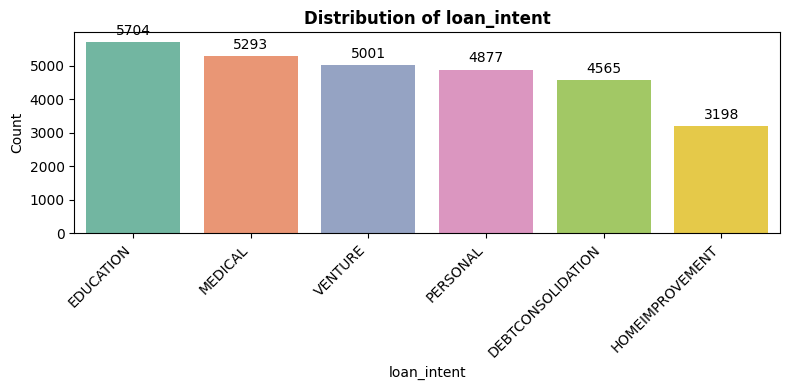


==================== loan_grade ====================
            Count  Percentage (%)
loan_grade                       
A            9402           32.83
B            9151           31.95
C            5699           19.90
D            3248           11.34
E             870            3.04
F             209            0.73
G              59            0.21


/tmp/ipykernel_851/2218469318.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette='Set2', order=val_counts.index)


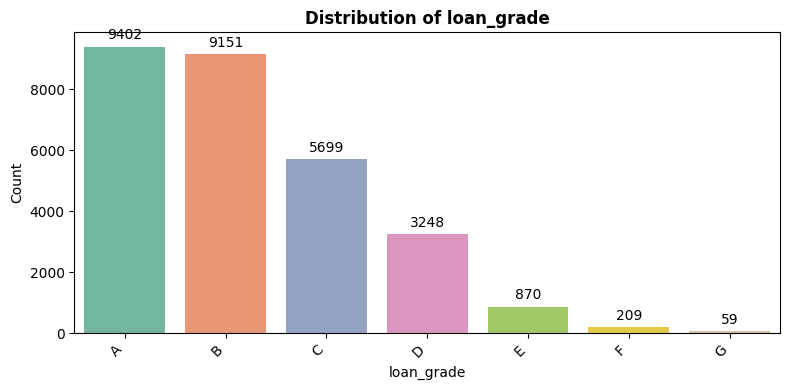


==================== cb_person_default_on_file ====================
                           Count  Percentage (%)
cb_person_default_on_file                       
N                          23535           82.18
Y                           5103           17.82


/tmp/ipykernel_851/2218469318.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette='Set2', order=val_counts.index)


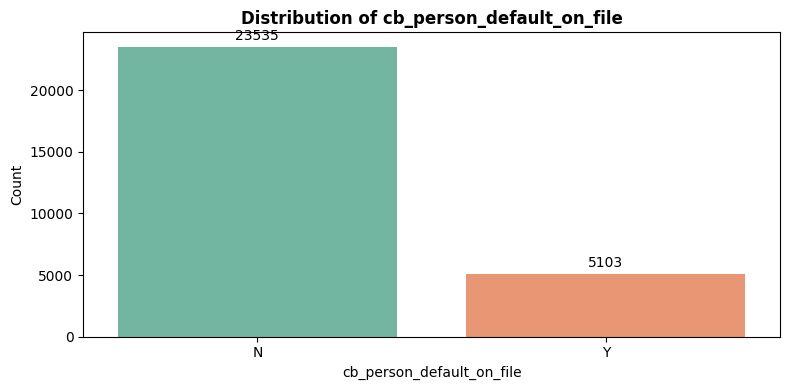

In [11]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    # 1. Print frequency and percentage breakdown
    print(f"\n==================== {col} ====================")
    val_counts = df[col].value_counts(dropna=False)
    percents = df[col].value_counts(normalize=True, dropna=False) * 100
    summary_df = pd.DataFrame({'Count': val_counts, 'Percentage (%)': percents.round(2)})
    print(summary_df)

    # 2. Plot Count Plot
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(data=df, x=col, palette='Set2', order=val_counts.index)
    plt.title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Count')

    # Rotate labels if categories are long
    if df[col].nunique() > 4:
        plt.xticks(rotation=45, ha='right')

    # Add exact count numbers on top of each bar
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                        textcoords='offset points')

    plt.tight_layout()
    plt.show()

In [31]:
initial_count = len(df)
df = df.loc[df['person_age'] <= 90]
print(f"Removed {initial_count - len(df)} corrupted rows where age > 90.")
print(f"New dataset shape: {df.shape}")

Removed 4 corrupted rows where age > 90.
New dataset shape: (28634, 12)


In [32]:
income_cap = df['person_income'].quantile(0.99)
# Clip the values above the 99th percentile to the cap limit
df['person_income'] = df['person_income'].clip(upper=income_cap)
print(f"Winsorization applied to 'person_income'. Capped at 99th percentile: {income_cap:.2f}")
print(f"New maximum value for person_income: {df['person_income'].max()}")

Winsorization applied to 'person_income'. Capped at 99th percentile: 230000.00
New maximum value for person_income: 230000


In [33]:
higher_emp_length = df[df['person_emp_length']>df["person_age"]]
print(f"Total rows with higher_emp_length : {len(higher_emp_length)}")
print(higher_emp_length[['person_age', 'person_emp_length', 'person_income', 'loan_status', 'loan_amnt']].sort_values(by='person_emp_length', ascending=False))

Total rows with higher_emp_length : 2
     person_age  person_emp_length  person_income  loan_status  loan_amnt
0            22              123.0          59000            1      35000
210          21              123.0         192000            0      20000


In [34]:
initial_count = len(df)
df = df.loc[
    (df['person_emp_length'] < df['person_age']) &
    ((df['person_age'] - df['person_emp_length']) >= 15)
]
print(f"Number of erroneous records cleaned: {initial_count - len(df)}")
print(f"Current dataset row count: {len(df)}")

Number of erroneous records cleaned: 2
Current dataset row count: 28632


In [35]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,28632.000000,28632.000000,28632.000000,28632.000000,28632.000000,28632.000000,28632.000000,28632.000000
mean,27.712140,64961.185597,4.780316,9655.331447,11.039701,0.216611,0.169489,5.793553
std,6.171989,38065.307299,4.035616,6327.798706,3.229409,0.411942,0.106361,4.037133
min,20.000000,4000.000000,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,39456.000000,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,55900.000000,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,80000.000000,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,84.000000,230000.000000,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


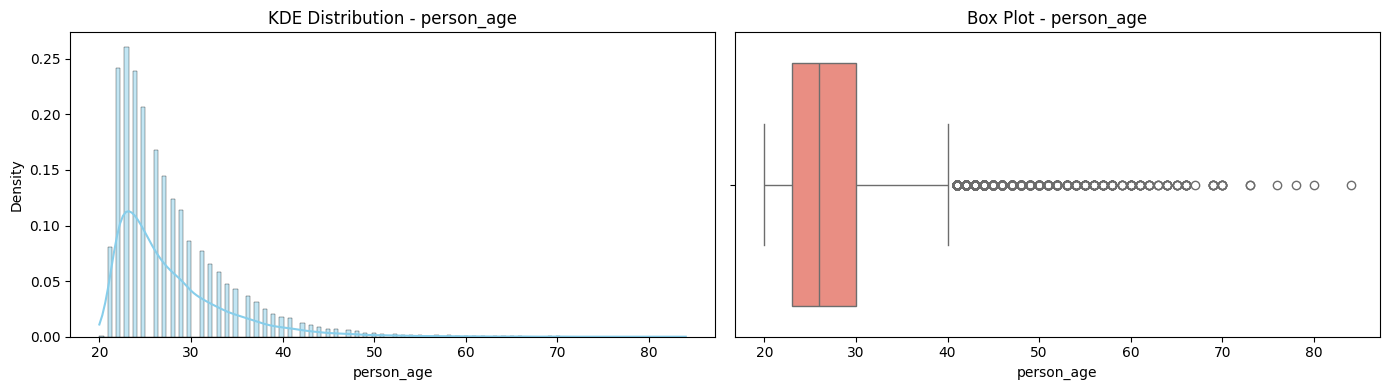

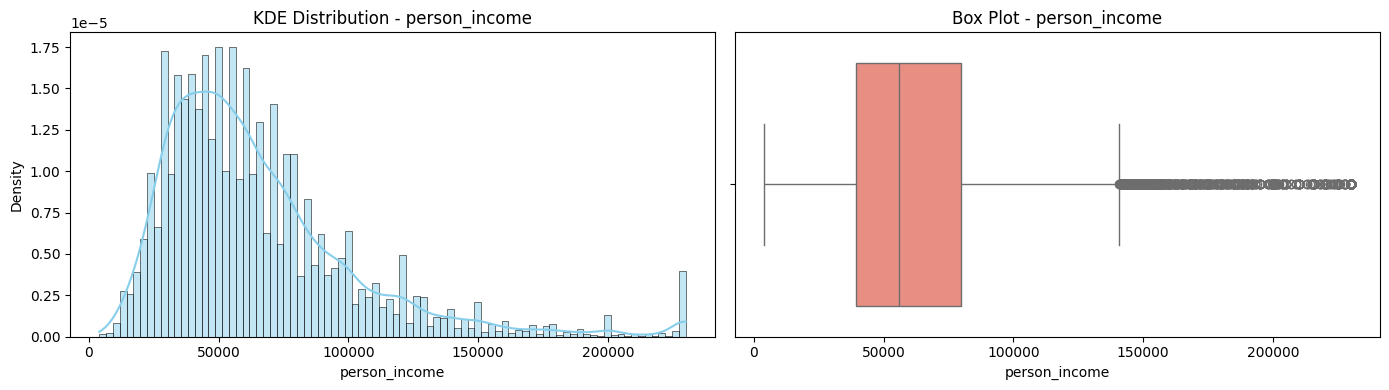

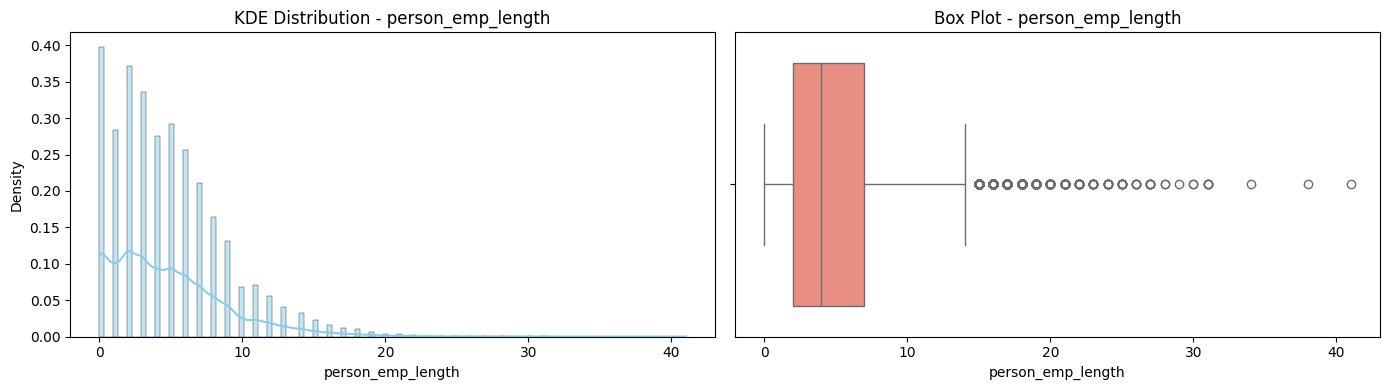

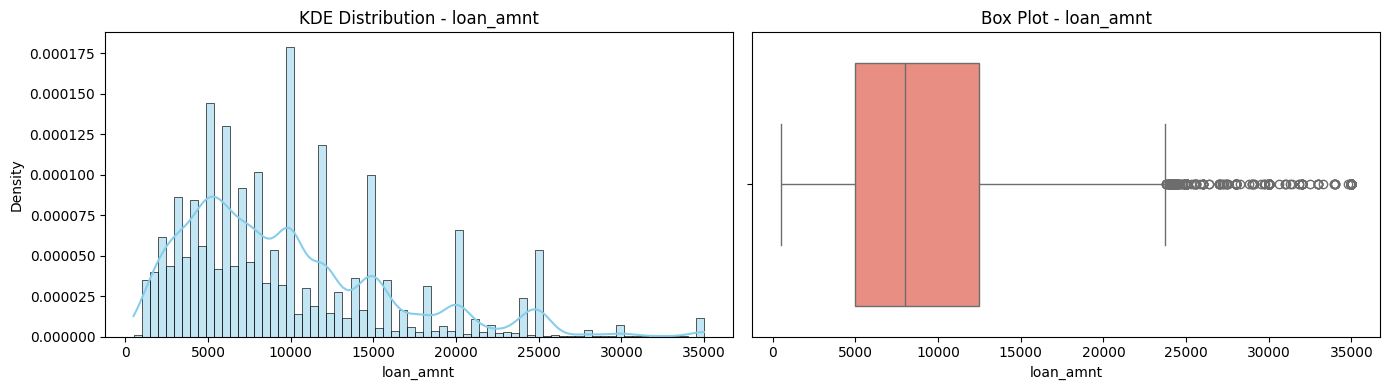

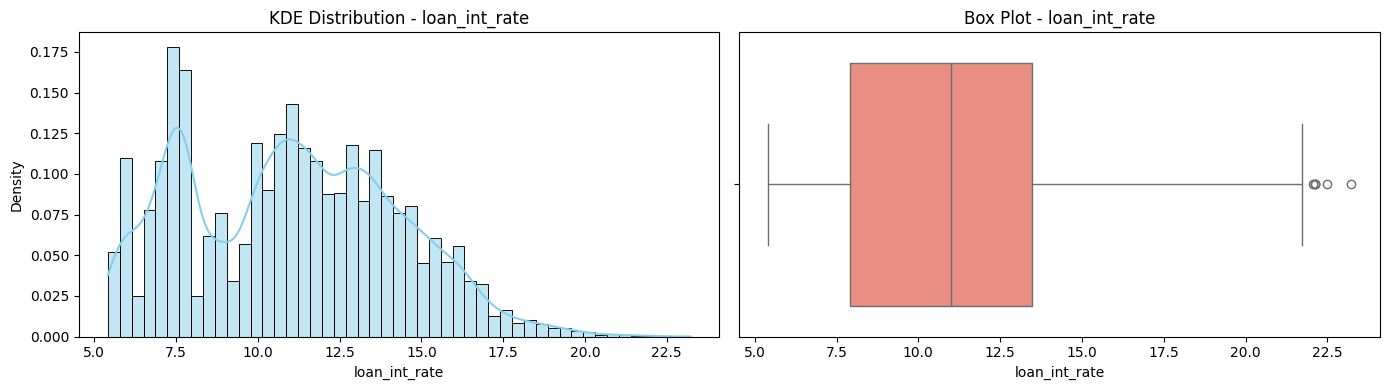

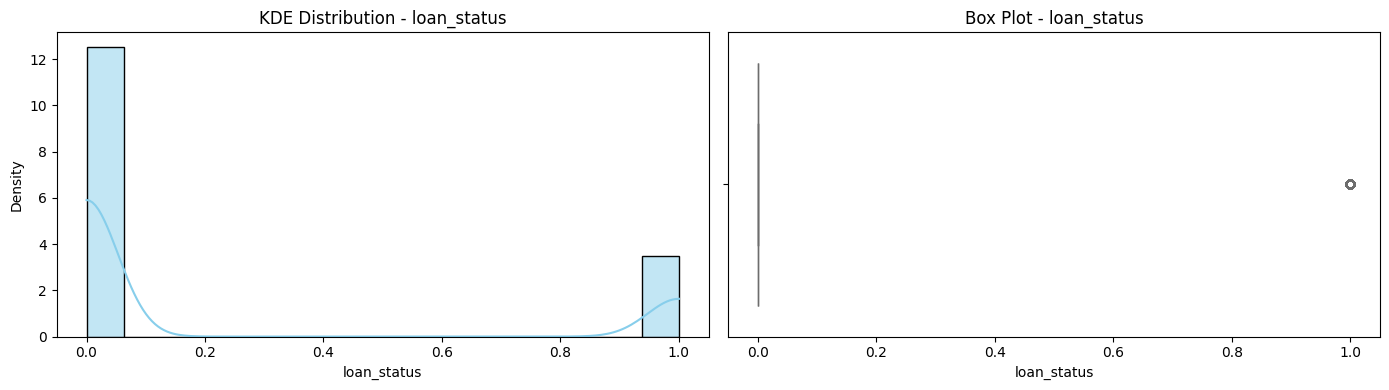

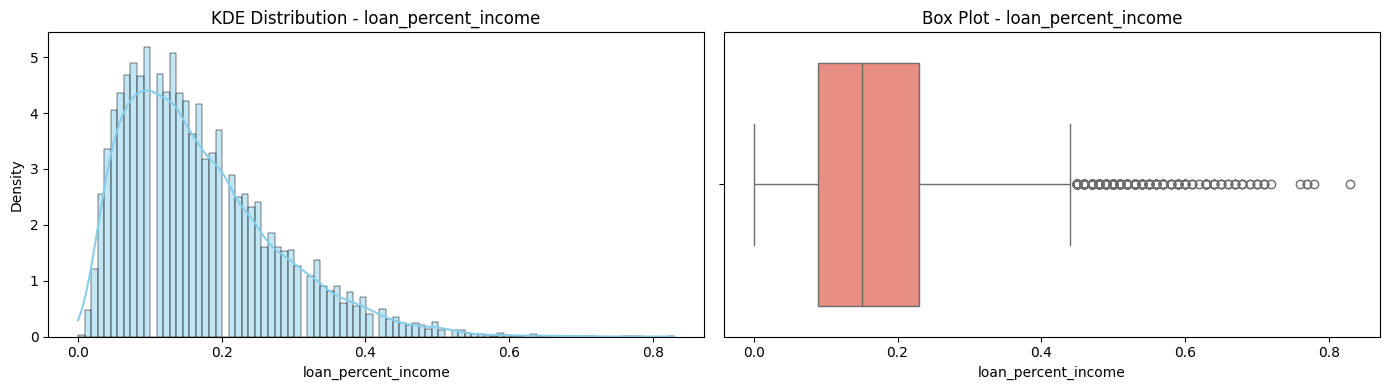

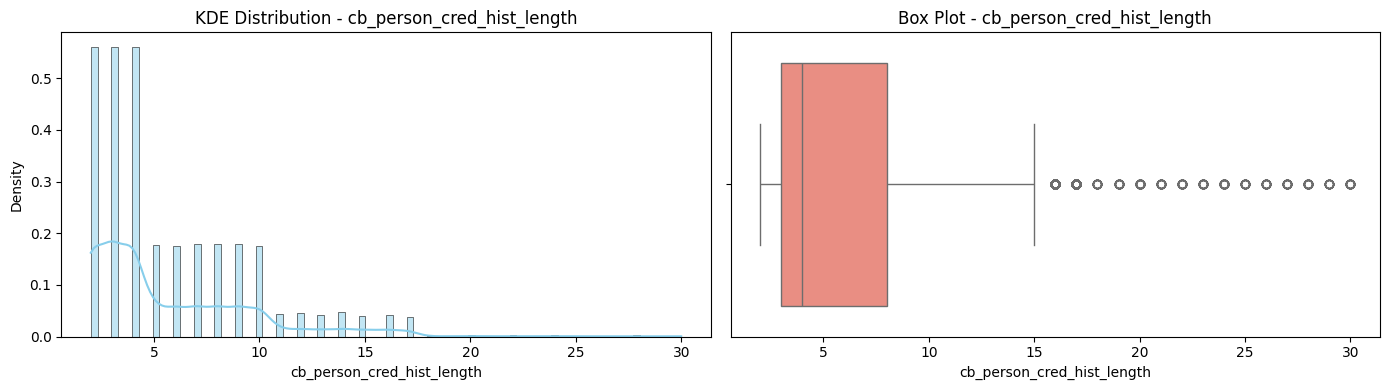

In [17]:
num_cols = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns
# Loop through each numerical column and plot KDE + Boxplot side by side
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # 1. KDE / Density Plot
    sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue', stat='density')
    axes[0].set_title(f'KDE Distribution - {col}', fontsize=12)
    axes[0].set_xlabel(col)

    # 2. Horizontal Box Plot
    sns.boxplot(x=df[col], ax=axes[1], color='salmon')
    axes[1].set_title(f'Box Plot - {col}', fontsize=12)
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

In [36]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"Detected categorical variables: {list(categorical_cols)}\n")

# 2. Apply One-Hot Encoding (drop_first=True to prevent Dummy Variable Trap)
# Only categorical columns are converted, numerical columns (age, income, etc.) remain as they are.
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3. Check the dimensions and new structure of the dataset after transformation.
print(f"orijinal data structure: {df.shape}")
print(f"New data structure: {df_encoded.shape}\n")

# Let's examine some of the newly created column names (especially dummy columns).
print("New Features:")
print(list(df_encoded.columns))

Detected categorical variables: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

orijinal data structure: (28632, 12)
New data structure: (28632, 23)

New Features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_Y']


--- Highest Positive Correlations (Risk Enhancers) with loan_status ---
loan_status                    1.000000
loan_percent_income            0.379534
loan_int_rate                  0.339307
loan_grade_D                   0.325856
person_home_ownership_RENT     0.236199
loan_grade_E                   0.184516
cb_person_default_on_file_Y    0.181867
loan_amnt                      0.113363
loan_grade_F                   0.100326
loan_grade_G                   0.084547
Name: loan_status, dtype: float64

--- Highest Negative Correlations with loan_status (Risk Mitigators) ---
cb_person_cred_hist_length   -0.015575
loan_grade_C                 -0.016359
loan_intent_PERSONAL         -0.021199
person_age                   -0.022498
loan_intent_EDUCATION        -0.056072
loan_intent_VENTURE          -0.078580
person_emp_length            -0.086486
loan_grade_B                 -0.096145
person_home_ownership_OWN    -0.104849
person_income                -0.213753
Name: loan_status, dtype: floa

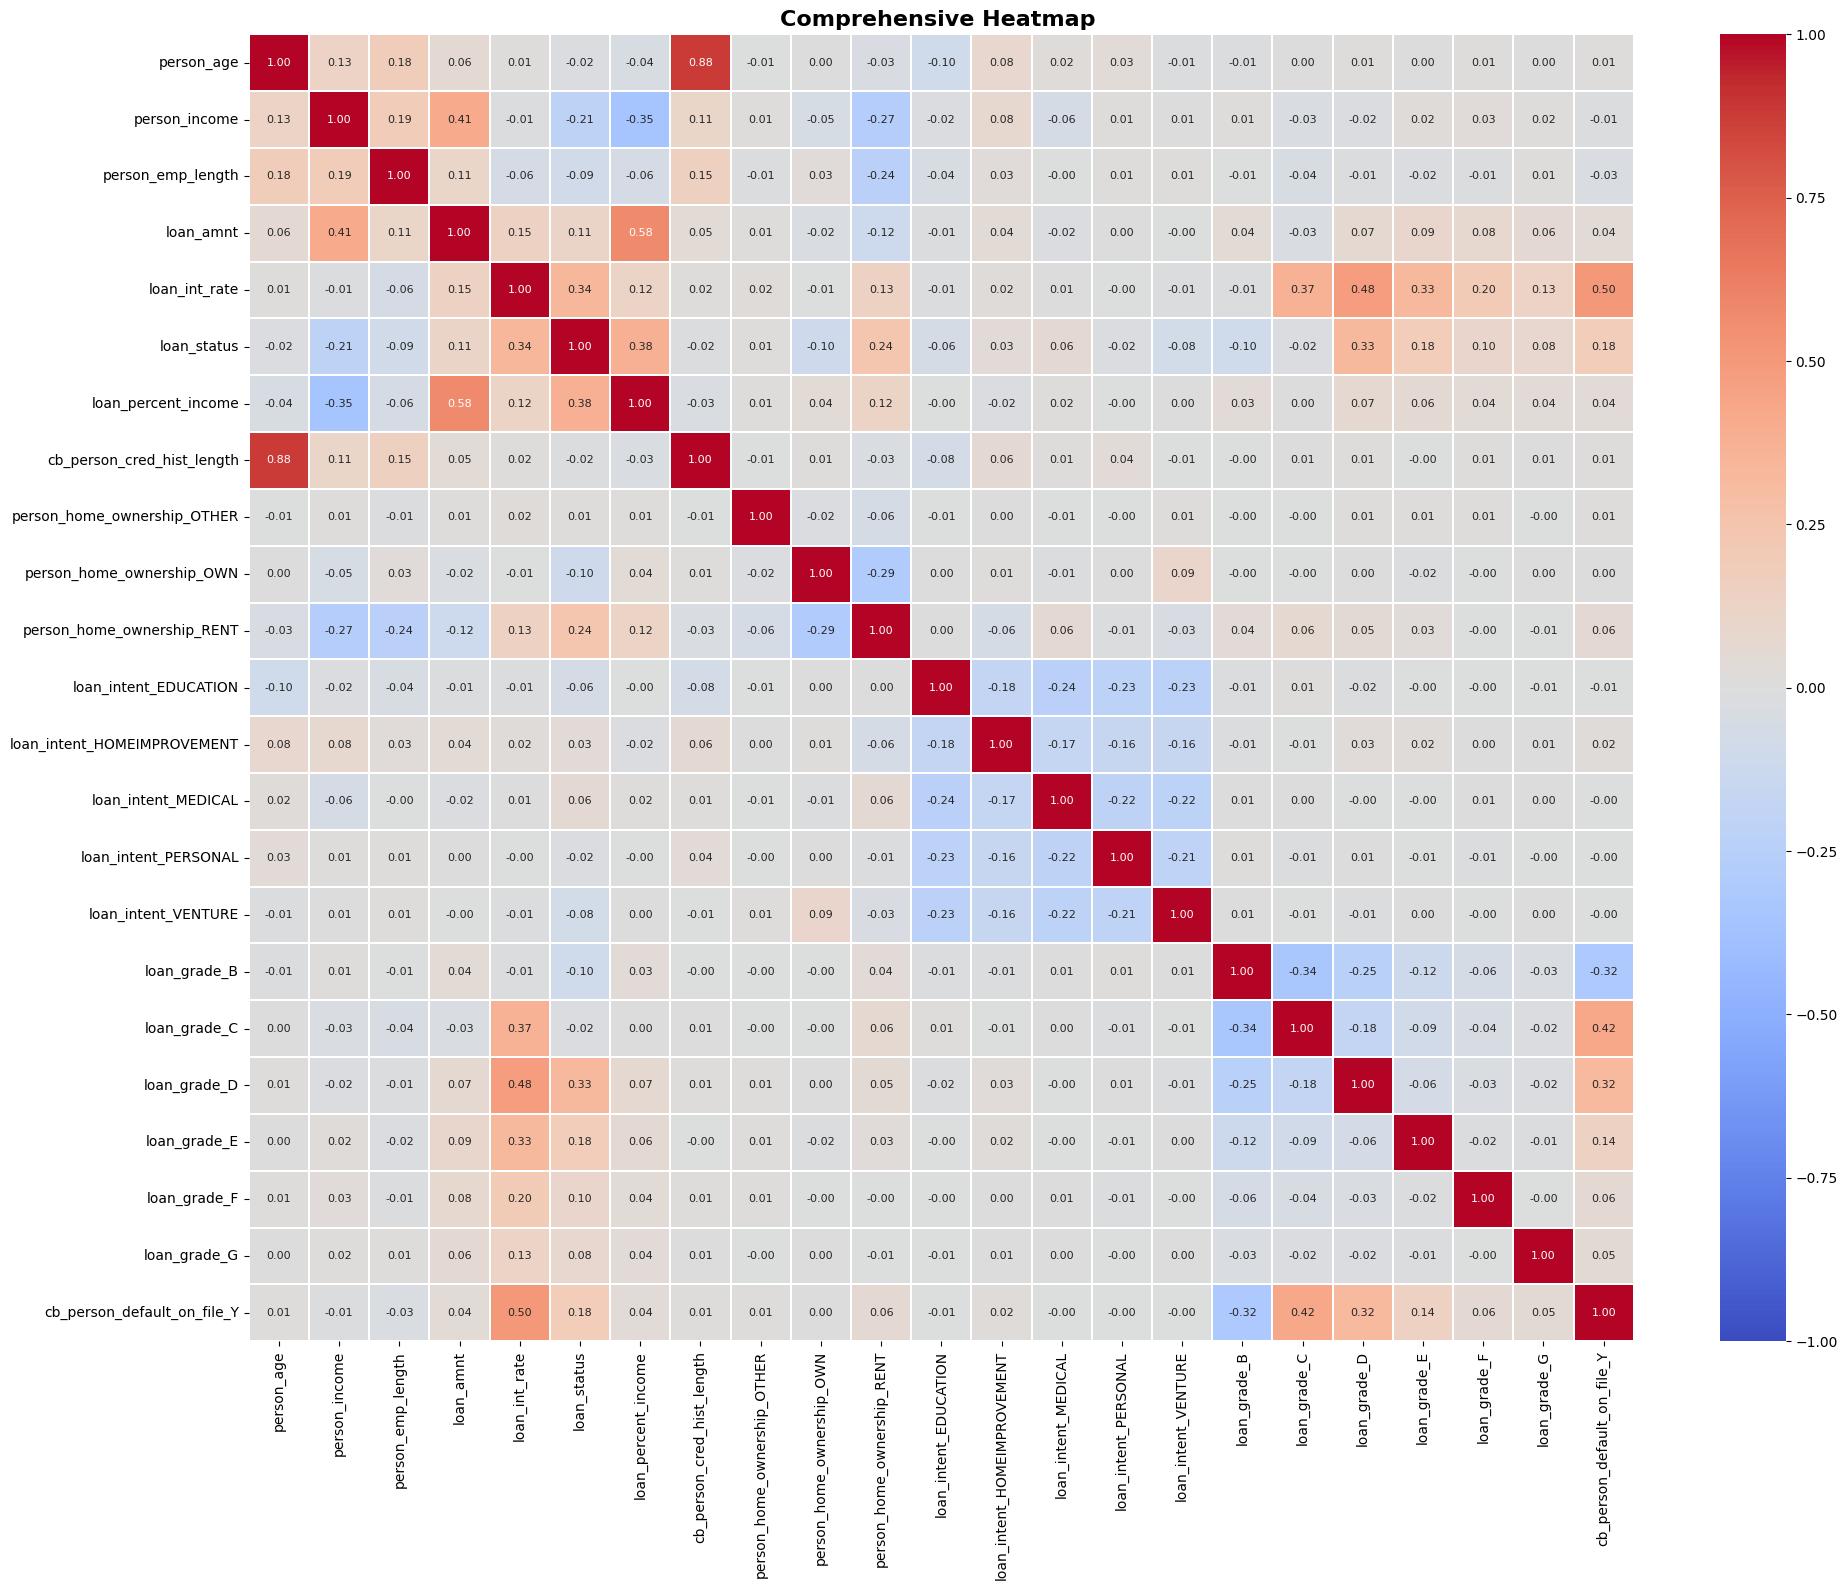

In [19]:
# 1. Calculate the correlation matrix from the encoded dataset.
corr_matrix_encoded = df_encoded.corr()

# 2. Isolate and rank only the correlations with 'loan_status' (target variable).
target_corr = corr_matrix_encoded['loan_status'].sort_values(ascending=False)

print("--- Highest Positive Correlations (Risk Enhancers) with loan_status ---")
print(target_corr.head(10))

print("\n--- Highest Negative Correlations with loan_status (Risk Mitigators) ---")
print(target_corr.tail(10))

# 3.Comprehensive Heatmap Drawing
plt.figure(figsize=(20, 16)) #The size was increased because the number of columns increased.
sns.heatmap(
    corr_matrix_encoded,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.1,
    annot_kws={"size": 8}
)
plt.title('Comprehensive Heatmap ', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
from sklearn.model_selection import train_test_split

In [41]:
from sklearn.model_selection import train_test_split, GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, precision_recall_curve, roc_curve
)

In [39]:
# 1. Distinguishing between independent variables (X) and target variable (y)
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# 2. Stratified Train/Test Split
# 80% of the data is allocated for training, 20% for testing. Class balance (stratify=y) is maintained.
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.30,random_state=42,stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Running Grid Search for Logistic Regression...
Running Grid Search for Random Forest...
Running Grid Search for XGBoost...

MODEL EVALUATION & THRESHOLD COMPARISON SUMMARY


,Model,ROC-AUC,Default Threshold,Accuracy (0.5),Precision (0.5),Recall (0.5),F1-Score (0.5),Optimal Threshold,Accuracy (Opt),Precision (Opt),Recall (Opt),F1-Score (Opt)
0,Logistic Regression,0.8716,0.5,0.8140,0.5499,0.7781,0.6444,0.6658,0.8591,0.6732,0.6797,0.6765
1,Random Forest,0.9307,0.5,0.9296,0.9379,0.7227,0.8164,0.5622,0.9318,0.9630,0.7125,0.8190
2,XGBoost,0.9455,0.5,0.9338,0.9492,0.7335,0.8275,0.5979,0.9355,0.9732,0.7222,0.8291


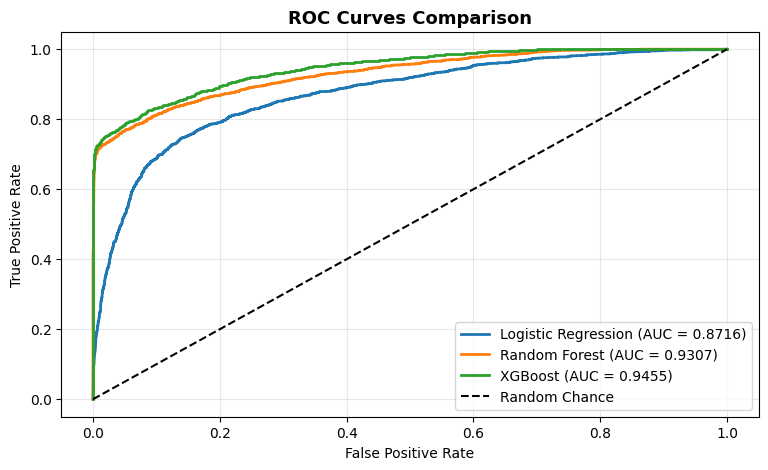

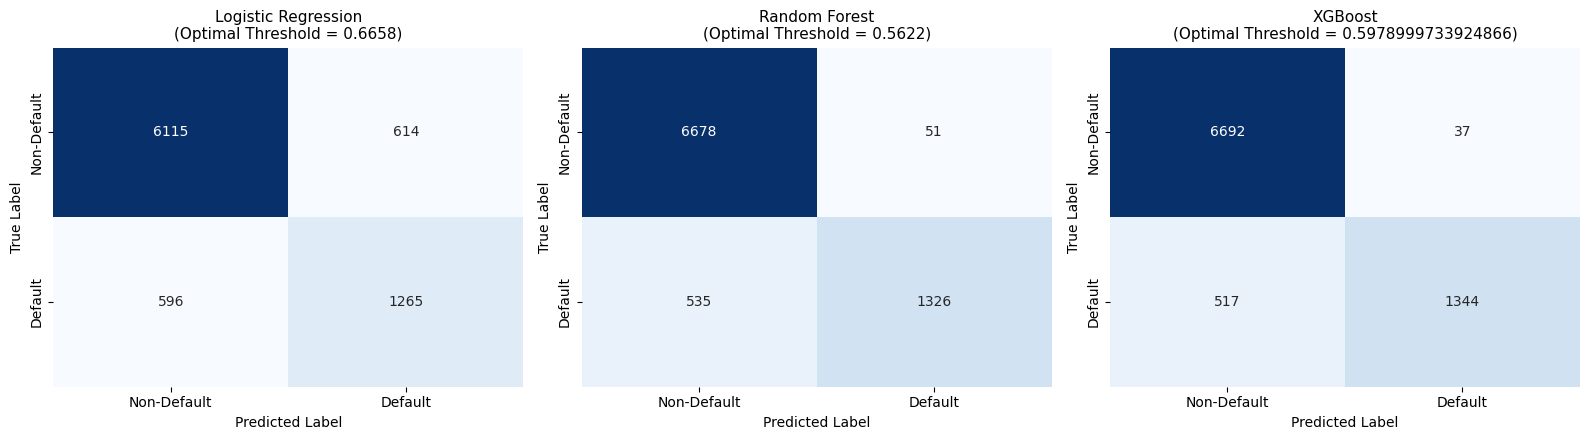

In [24]:
models_config = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'scaled': True,
        'params': {
            'C': [0.01, 0.1, 1.0, 10.0],
            'solver': ['lbfgs', 'liblinear'],
            'class_weight': [None, 'balanced']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'scaled': False,
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [10, 15, 20],
            'min_samples_split': [2, 5],
            'class_weight': [None, 'balanced']
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
        'scaled': False,
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 6, 8],
            'learning_rate': [0.01, 0.1, 0.2],
            'scale_pos_weight': [1, (len(y_train) - sum(y_train)) / sum(y_train)]
        }
    }
}

# -------------------------------------------------------------------
# 3. RUN GRID SEARCH & THRESHOLD OPTIMIZATION
# -------------------------------------------------------------------
results = []
best_estimators = {}
confusion_matrices = {}

for name, config in models_config.items():
    print(f"Running Grid Search for {name}...")

    # Select scaled vs raw data based on model requirements
    X_tr = X_train_scaled if config['scaled'] else X_train
    X_te = X_test_scaled if config['scaled'] else X_test

    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        scoring='roc_auc',
        cv=3,  # 3-fold cross-validation
        n_jobs=-1
    )
    grid.fit(X_tr, y_train)

    best_model = grid.best_estimator_
    best_estimators[name] = best_model

    # Get predicted probabilities
    y_probs = best_model.predict_proba(X_te)[:, 1]

    # Threshold Optimization via Precision-Recall Curve (Maximizing F1-Score)
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

    # Predictions at Default (0.5) vs Optimal Threshold
    y_pred_default = (y_probs >= 0.5).astype(int)
    y_pred_optimal = (y_probs >= optimal_threshold).astype(int)

    # Record full metrics
    results.append({
        'Model': name,
        'ROC-AUC': round(roc_auc_score(y_test, y_probs), 4),
        'Default Threshold': 0.5,
        'Accuracy (0.5)': round(accuracy_score(y_test, y_pred_default), 4),
        'Precision (0.5)': round(precision_score(y_test, y_pred_default), 4),
        'Recall (0.5)': round(recall_score(y_test, y_pred_default), 4),
        'F1-Score (0.5)': round(f1_score(y_test, y_pred_default), 4),
        'Optimal Threshold': round(optimal_threshold, 4),
        'Accuracy (Opt)': round(accuracy_score(y_test, y_pred_optimal), 4),
        'Precision (Opt)': round(precision_score(y_test, y_pred_optimal), 4),
        'Recall (Opt)': round(recall_score(y_test, y_pred_optimal), 4),
        'F1-Score (Opt)': round(f1_score(y_test, y_pred_optimal), 4),
    })

    confusion_matrices[name] = confusion_matrix(y_test, y_pred_optimal)

# Create summary DataFrame
results_df = pd.DataFrame(results)

# -------------------------------------------------------------------
# 4. DISPLAY RESULTS TABLE
# -------------------------------------------------------------------
print("\n" + "="*85)
print("MODEL EVALUATION & THRESHOLD COMPARISON SUMMARY")
print("="*85)
display(results_df)

# -------------------------------------------------------------------
# 5. VISUALIZATIONS (ROC CURVES & CONFUSION MATRICES)
# -------------------------------------------------------------------
# Plot 1: ROC Curves Comparison
plt.figure(figsize=(9, 5))
for name, config in models_config.items():
    X_te = X_test_scaled if config['scaled'] else X_test
    y_probs = best_estimators[name].predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_val = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: Confusion Matrices at Optimal Thresholds
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for i, (name, cm) in enumerate(confusion_matrices.items()):
    opt_thresh = results_df.loc[results_df['Model'] == name, 'Optimal Threshold'].values[0]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Non-Default', 'Default'],
                yticklabels=['Non-Default', 'Default'])
    axes[i].set_title(f'{name}\n(Optimal Threshold = {opt_thresh})', fontsize=11)
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [40]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, precision_recall_curve, roc_curve
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - AUC: 0.8073 - loss: 0.5442 - val_AUC: 0.8827 - val_loss: 0.4055 - learning_rate: 0.0010
Epoch 2/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8695 - loss: 0.4486 - val_AUC: 0.8929 - val_loss: 0.3578 - learning_rate: 0.0010
Epoch 3/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8799 - loss: 0.4297 - val_AUC: 0.8972 - val_loss: 0.3570 - learning_rate: 0.0010
Epoch 4/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8858 - loss: 0.4198 - val_AUC: 0.9018 - val_loss: 0.3450 - learning_rate: 0.0010
Epoch 5/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8934 - loss: 0.4037 - val_AUC: 0.9067 - val_loss: 0.3574 - learning_rate: 0.0010
Epoch 6/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8974 - loss: 0.3951 - val_AUC: 0.9072 - val_loss: 0.3323 - learning_rate: 0.0010
Epoch 7/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9000 - loss: 0.3900 - val_AUC: 0.9094 - val_loss: 0.3216 - learning_rate: 0.00

,Model,ROC-AUC,Default Threshold,Accuracy (0.5),Precision (0.5),Recall (0.5),F1-Score (0.5),Optimal Threshold,Accuracy (Opt),Precision (Opt),Recall (Opt),F1-Score (Opt)
0,Deep Learning (MLP),0.9226,0.5,0.9003,0.7784,0.755,0.7665,0.6999,0.9268,0.935,0.7114,0.8081


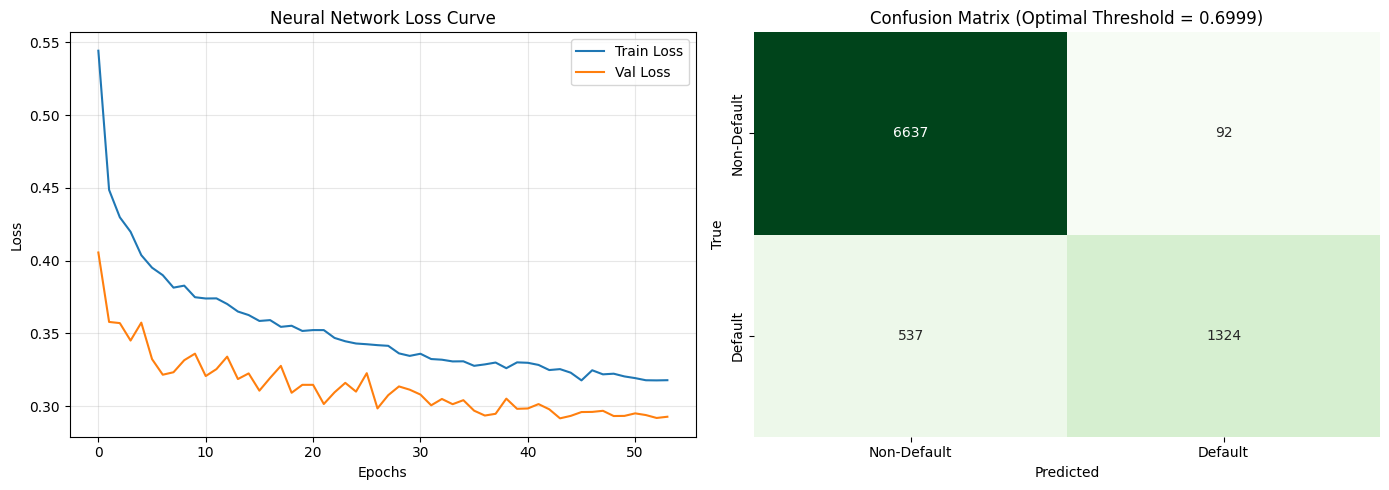

In [26]:
input_dim = X_train_scaled.shape[1]

model = Sequential([
    # Input & First Hidden Layer
    Dense(64, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),

    # Second Hidden Layer
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Third Hidden Layer
    Dense(16, activation='relu'),

    # Output Layer (Binary Classification)
    Dense(1, activation='sigmoid')
])

# Compile the Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['AUC']
)

# -------------------------------------------------------------------
# 2. HANDLE CLASS IMBALANCE & CALLBACKS
# -------------------------------------------------------------------
# Calculate class weights for training
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

# Callbacks to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

# -------------------------------------------------------------------
# 3. TRAIN THE MODEL
# -------------------------------------------------------------------
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# -------------------------------------------------------------------
# 4. EVALUATION & THRESHOLD OPTIMIZATION
# -------------------------------------------------------------------
# Get probability predictions on test set
y_probs = model.predict(X_test_scaled).ravel()

# Calculate optimal decision threshold (Maximizing F1-Score)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

# Binary predictions based on default (0.5) vs optimal threshold
y_pred_default = (y_probs >= 0.5).astype(int)
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)

# Print Summary Table
dl_results = pd.DataFrame([{
    'Model': 'Deep Learning (MLP)',
    'ROC-AUC': round(roc_auc_score(y_test, y_probs), 4),
    'Default Threshold': 0.5,
    'Accuracy (0.5)': round(accuracy_score(y_test, y_pred_default), 4),
    'Precision (0.5)': round(precision_score(y_test, y_pred_default), 4),
    'Recall (0.5)': round(recall_score(y_test, y_pred_default), 4),
    'F1-Score (0.5)': round(f1_score(y_test, y_pred_default), 4),
    'Optimal Threshold': round(optimal_threshold, 4),
    'Accuracy (Opt)': round(accuracy_score(y_test, y_pred_optimal), 4),
    'Precision (Opt)': round(precision_score(y_test, y_pred_optimal), 4),
    'Recall (Opt)': round(recall_score(y_test, y_pred_optimal), 4),
    'F1-Score (Opt)': round(f1_score(y_test, y_pred_optimal), 4),
}])

display(dl_results)

# -------------------------------------------------------------------
# 5. VISUALIZATIONS (TRAINING HISTORY & CONFUSION MATRIX)
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Neural Network Loss Curve')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Confusion Matrix at Optimal Threshold
cm = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default'])
axes[1].set_title(f'Confusion Matrix (Optimal Threshold = {optimal_threshold:.4f})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

Searching for optimal XGBoost hyperparameters...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

BEST HYPERPARAMETERS FOUND:
  • subsample: 1.0
  • scale_pos_weight: 3.616908546417876
  • reg_lambda: 1.0
  • reg_alpha: 1.0
  • n_estimators: 300
  • min_child_weight: 1
  • max_depth: 7
  • learning_rate: 0.2
  • gamma: 0.2
  • colsample_bytree: 0.6

Best Cross-Validation ROC-AUC: 0.9435

FINAL TEST SET PERFORMANCE


,Metric,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Default Cutoff (0.5),0.9164,0.8231,0.7824,0.8022,0.944
1,Optimal Threshold (0.6903),0.9327,0.9314,0.7442,0.8274,0.944


/tmp/ipykernel_851/2462811669.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, ax=axes[0, 0], palette='viridis')


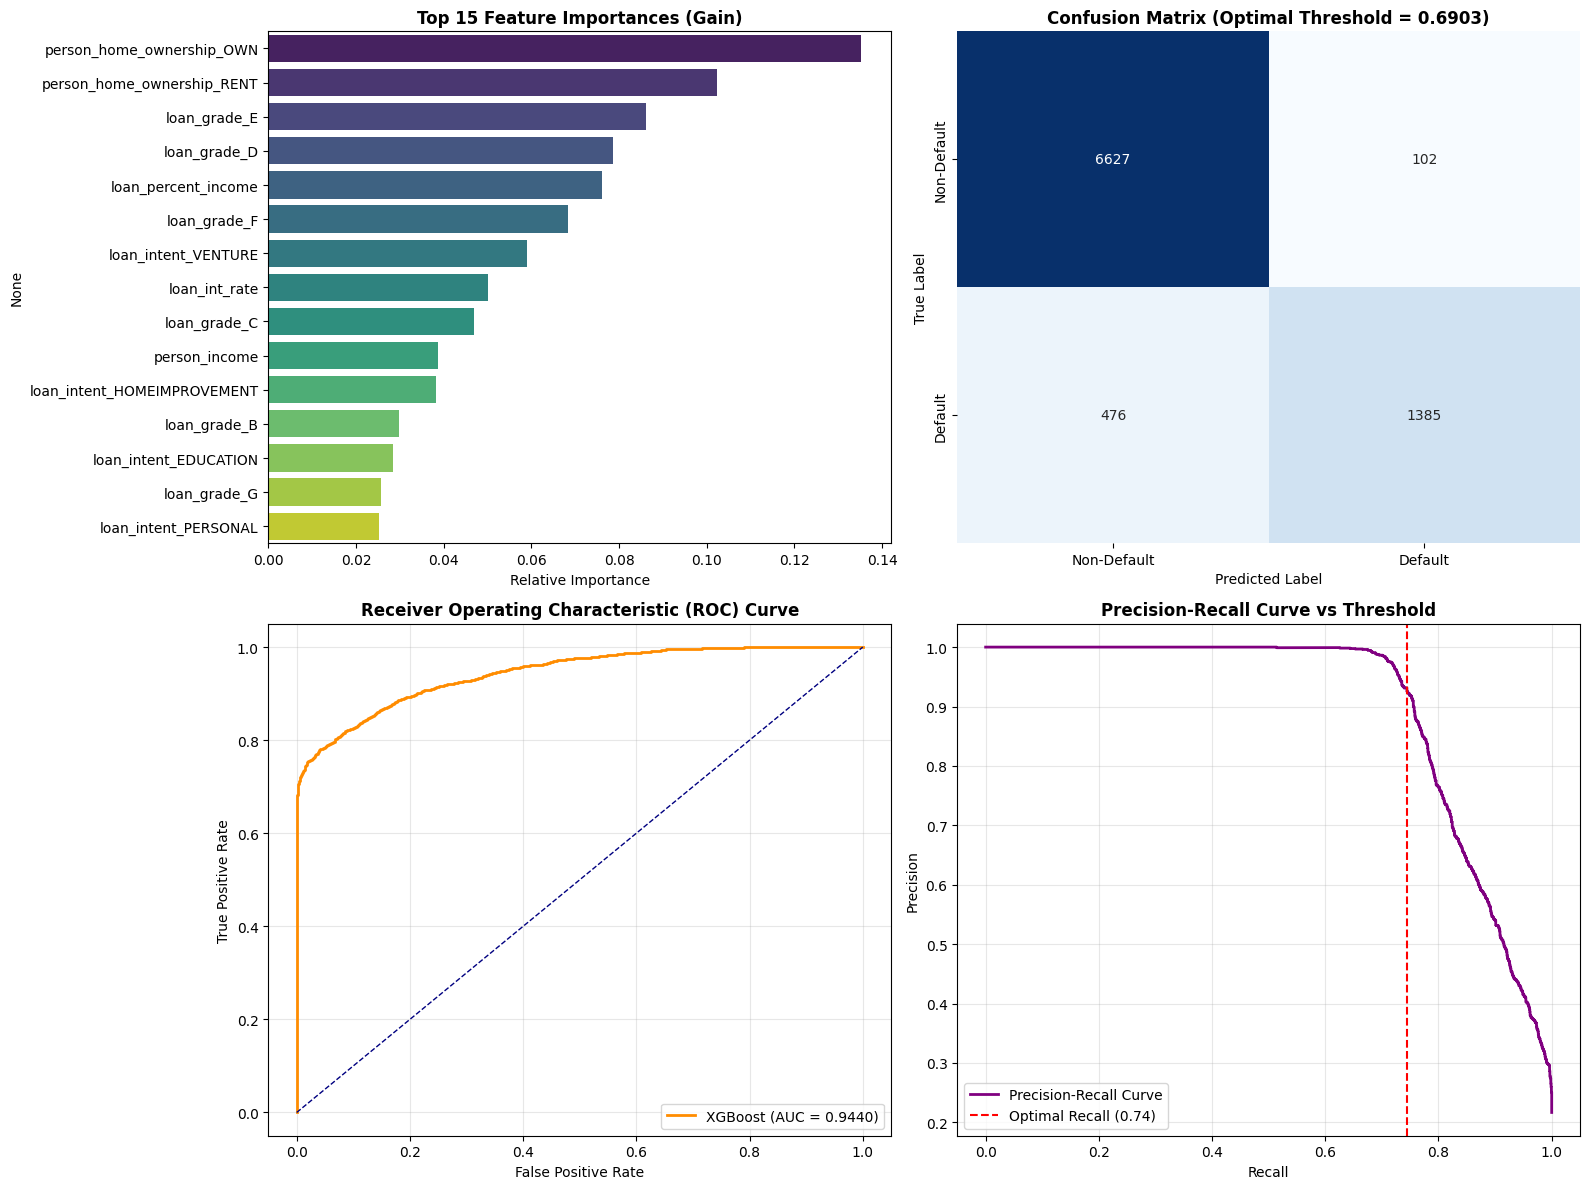

In [42]:
scale_pos_ratio = (len(y_train) - sum(y_train)) / sum(y_train)
xgb_param_dist = {
    # Tree Structure & Capacity
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9, 11],
    'min_child_weight': [1, 3, 5, 7],

    # Learning Rate & Step Size
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],

    # Random Subsampling (Prevents Overfitting)
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],

    # Regularization & Tree Splitting
    'gamma': [0, 0.1, 0.2, 0.5, 1.0],               # Minimum loss reduction for split
    'reg_alpha': [0, 0.01, 0.1, 1.0],               # L1 Regularization
    'reg_lambda': [0.5, 1.0, 2.0, 5.0],             # L2 Regularization

    # Class Imbalance Balance Weight
    'scale_pos_weight': [1.0, scale_pos_ratio]
}

# Base Estimator
base_xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# -------------------------------------------------------------------
# 3. RUN RANDOMIZED SEARCH CV
# -------------------------------------------------------------------
print("Searching for optimal XGBoost hyperparameters...")
xgb_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=xgb_param_dist,
    n_iter=30,             # Tests 30 distinct combinations
    scoring='roc_auc',
    cv=5,                  # 5-fold cross validation
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

print("\n==========================================")
print("BEST HYPERPARAMETERS FOUND:")
print("==========================================")
for param, value in xgb_search.best_params_.items():
    print(f"  • {param}: {value}")
print(f"\nBest Cross-Validation ROC-AUC: {xgb_search.best_score_:.4f}")

# -------------------------------------------------------------------
# 4. THRESHOLD OPTIMIZATION & TEST EVALUATION
# -------------------------------------------------------------------
y_probs = best_xgb.predict_proba(X_test)[:, 1]

# Precision-Recall Curve to find best F1 threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

# Binary Predictions
y_pred_default = (y_probs >= 0.5).astype(int)
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)

# Results Summary
results_summary = pd.DataFrame([{
    'Metric': 'Default Cutoff (0.5)',
    'Accuracy': round(accuracy_score(y_test, y_pred_default), 4),
    'Precision': round(precision_score(y_test, y_pred_default), 4),
    'Recall': round(recall_score(y_test, y_pred_default), 4),
    'F1-Score': round(f1_score(y_test, y_pred_default), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_probs), 4)
}, {
    'Metric': f'Optimal Threshold ({optimal_threshold:.4f})',
    'Accuracy': round(accuracy_score(y_test, y_pred_optimal), 4),
    'Precision': round(precision_score(y_test, y_pred_optimal), 4),
    'Recall': round(recall_score(y_test, y_pred_optimal), 4),
    'F1-Score': round(f1_score(y_test, y_pred_optimal), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_probs), 4)
}])

print("\n" + "="*70)
print("FINAL TEST SET PERFORMANCE")
print("="*70)
display(results_summary)

# -------------------------------------------------------------------
# 5. VISUALIZATIONS: FEATURE IMPORTANCE & DIAGNOSTIC PLOTS
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Top 15 Feature Importances
importances = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
sns.barplot(x=importances.values, y=importances.index, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Top 15 Feature Importances (Gain)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Relative Importance')

# Chart 2: Confusion Matrix at Optimal Threshold
cm = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1], cbar=False,
            xticklabels=['Non-Default', 'Default'], yticklabels=['Non-Default', 'Default'])
axes[0, 1].set_title(f'Confusion Matrix (Optimal Threshold = {optimal_threshold:.4f})', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Predicted Label')
axes[0, 1].set_ylabel('True Label')

# Chart 3: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc_val = roc_auc_score(y_test, y_probs)
axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {auc_val:.4f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[1, 0].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(True, alpha=0.3)

# Chart 4: Precision-Recall Curve
axes[1, 1].plot(recalls, precisions, color='purple', lw=2, label='Precision-Recall Curve')
axes[1, 1].axvline(x=recall_score(y_test, y_pred_optimal), color='red', linestyle='--', label=f'Optimal Recall ({recall_score(y_test, y_pred_optimal):.2f})')
axes[1, 1].set_title('Precision-Recall Curve vs Threshold', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].legend(loc='lower left')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
import joblib
import json

# -------------------------------------------------------------------
# METHOD 1: SAVE EVERYTHING IN A SINGLE JOBLIB BUNDLE (RECOMMENDED)
# Stores model, optimal threshold, and expected feature column order
# -------------------------------------------------------------------
model_bundle = {
    'model': best_xgb,
    'optimal_threshold': optimal_threshold,  # 0.6903
    'feature_names': list(X.columns)
}

joblib.dump(model_bundle, 'xgboost_loan_model.joblib')
print("Model bundle saved successfully as 'xgboost_loan_model.joblib'")


# -------------------------------------------------------------------
# METHOD 2: SAVE AS NATIVE XGBOOST JSON FORMAT
# Best for multi-language deployment (C++, Java, Go, C#)
# -------------------------------------------------------------------
# Save model structure
best_xgb.save_model('xgboost_loan_model.json')

# Save metadata separately
metadata = {
    'optimal_threshold': float(optimal_threshold),
    'feature_names': list(X.columns),
    'roc_auc_score': 0.9441,
    'f1_score_optimal': 0.8274
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("Native XGBoost model saved as 'xgboost_loan_model.json'")

Model bundle saved successfully as 'xgboost_loan_model.joblib'
Native XGBoost model saved as 'xgboost_loan_model.json'


In [45]:
import os
print("Files are saved in this folder:")
print(os.path.abspath('xgboost_loan_model.joblib'))

Files are saved in this folder:
/content/xgboost_loan_model.joblib


In [46]:
import joblib
import pandas as pd

# 1. Load the model bundle
loaded_bundle = joblib.load('xgboost_loan_model.joblib')
model = loaded_bundle['model']
optimal_threshold = loaded_bundle['optimal_threshold']
expected_features = loaded_bundle['feature_names']

# 2. Example function for real-time inference
def predict_loan_default(new_data_df):
    """
    Accepts a DataFrame of new loan applicants and applies the optimal decision threshold.
    """
    # Ensure features match the exact column order used during training
    X_new = new_data_df[expected_features]

    # Calculate predicted probabilities
    probabilities = model.predict_proba(X_new)[:, 1]

    # Apply saved optimal threshold (0.6903)
    predictions = (probabilities >= optimal_threshold).astype(int)

    return pd.DataFrame({
        'Default_Probability': probabilities.round(4),
        'Predicted_Default_Status': predictions
    })

# --- Usage Example ---
# results = predict_loan_default(new_applicant_df)
# print(results)

--- 1. GLOBAL ANALYSIS: General Rules for All Clients ---


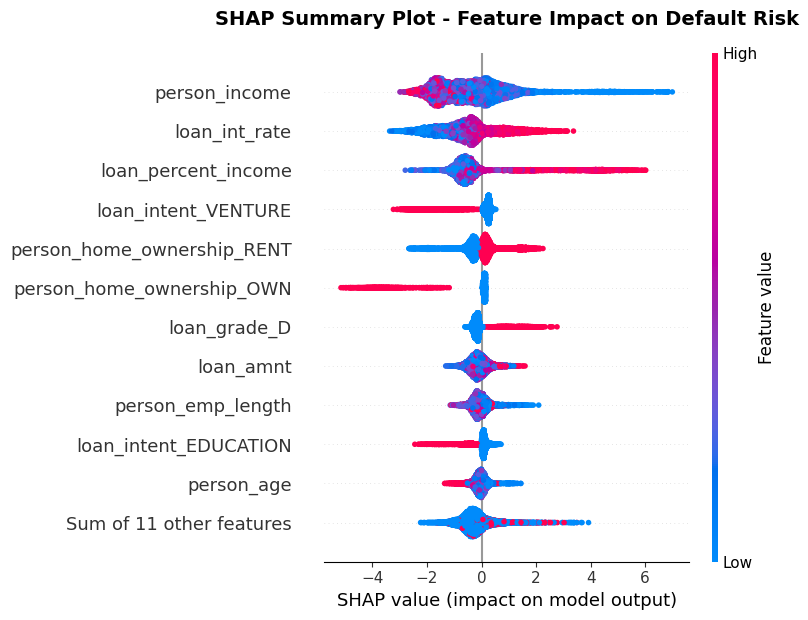


--- 2. INDIVIDUAL ANALYSIS: A Specific Customer's Credit Decision ---


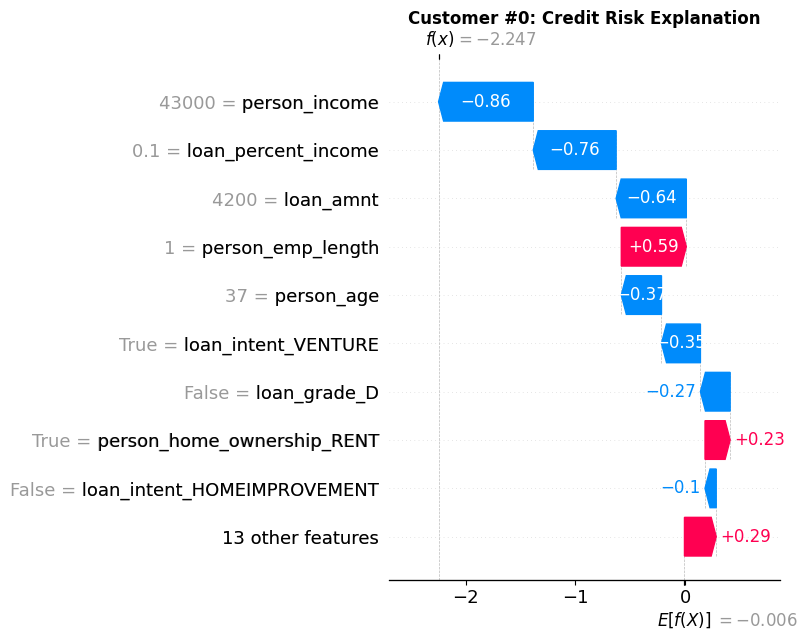

In [48]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize Explainer (Replace 'best_xgb' with 'xgb_tuned' if that's what you named it)
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer(X_test)

# ---------------------------------------------------------
# IMAGE 1: GLOBAL ANALYSIS (Beeswarm / Summary Plot)
# ---------------------------------------------------------
print("--- 1. GLOBAL ANALYSIS: General Rules for All Clients ---")
plt.figure(figsize=(10, 6))

# Modern SHAP beeswarm plot using the Explanation object
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title("SHAP Summary Plot - Feature Impact on Default Risk", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# IMAGE 2: INDIVIDUAL CUSTOMER ANALYSIS (Waterfall Plot)
# ---------------------------------------------------------
print("\n--- 2. INDIVIDUAL ANALYSIS: A Specific Customer's Credit Decision ---")

customer_index = 0  # Inspecting the 1st applicant in X_test

plt.figure(figsize=(9, 5))
shap.plots.waterfall(shap_values[customer_index], max_display=10, show=False)
plt.title(f"Customer #{customer_index}: Credit Risk Explanation", fontsize=12, fontweight='bold', pad=25)
plt.tight_layout()
plt.show()